In [1]:
import sys
sys.path.append('..')
import os
import torch
import cv2
import matplotlib.pyplot as plt
from src.model import HuggingFaceLoFTR
from src.visualization import draw_matches

In [2]:
# Set computational execution device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_path = "../models/loftr_finetuned"

# Initialize & Load Model
if os.path.exists(os.path.join(model_path, "loftr_weights.pth")):
    print(f"Loading your saved weights from: {model_path}")
    model = HuggingFaceLoFTR.from_pretrained(model_path, device=device)
else:
    print("No local weights found; initializing the base model 'outdoor'...")
    model = HuggingFaceLoFTR(pretrained_config="outdoor").to(device)

model.eval()

Loading your saved weights from: ../models/loftr_finetuned
Initializing the LoFTR model (configuration: 'outdoor')...
The model weights have been successfully loaded from: ../models/loftr_finetuned\loftr_weights.pth


HuggingFaceLoFTR(
  (model): LoFTR(
    (backbone): ResNetFPN_8_2(
      (conv1): Conv2d(1, 128, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=Fal

In [3]:
# Load Sample Seasonal Patches
img0_path = "../data/processed/season_a/patch_0100.png"
img1_path = "../data/processed/season_b/patch_0100.png"

img0 = cv2.imread(img0_path, cv2.IMREAD_GRAYSCALE)
img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)

if img0 is None or img1 is None:
    raise FileNotFoundError("No patches were found! Please check if the following has been done 01_dataset_creation.ipynb")

# Resize to standardized dimensions
img0_res = cv2.resize(img0, (512, 512))
img1_res = cv2.resize(img1, (512, 512))

# Preprocess arrays to PyTorch floating point tensors
t0 = torch.from_numpy(img0_res).float()[None, None] / 255.0
t1 = torch.from_numpy(img1_res).float()[None, None] / 255.0

In [6]:
# Keypoint Matching Inference
model.eval()
with torch.no_grad():
    out = model(t0.to(device), t1.to(device))
pts0 = out['keypoints0'].cpu().numpy()
pts1 = out['keypoints1'].cpu().numpy()
confs = out['confidence'].cpu().numpy()

print(f"Matches found: {len(pts0)}")

Matches found: 164


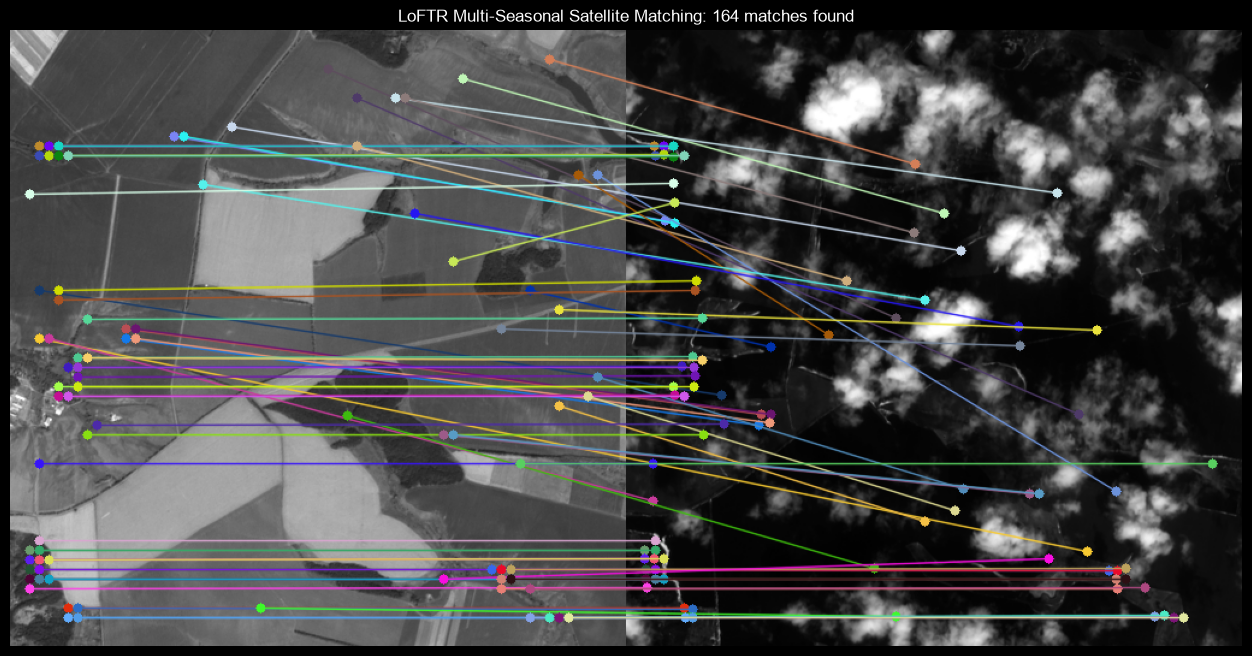

In [5]:
# Render Visualization
vis_img = draw_matches(img0_res, img1_res, pts0, pts1, confs, max_draw=120, conf_thresh=0.35)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB) if len(vis_img.shape) == 3 else vis_img)
plt.axis('off')
plt.title(f"LoFTR Multi-Seasonal Satellite Matching: {len(pts0)} matches found")
plt.show()